In [2]:
import os, sys
sys.path.append(os.getcwd())
from datetime import datetime

MODEL_FOLDER = "trading_models"
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
MODEL_PATH = f"./{MODEL_FOLDER}"
os.makedirs(MODEL_PATH, exist_ok=True)
print(f"Model path: {MODEL_PATH}")


Model path: ./trading_models


In [4]:
import logging

import pandas as pd
import numpy as np
import tensorflow as tf

import market_scraper as ms
from market_scraper.core.utilities import find_duplicates_and_time_gaps
from market_scraper.exchanges.binance.kline_dataclass import KlineKeys
from market_scraper.exchanges.bybit import OpenInterestKeys, LongShortRatioKeys

import binance_labelling as bl
from binance_labelling import LabellingCols

from engineered_features import (
    apply_calculation_to_segments, derive_binance_eng_features,
    derive_bybit_eng_features, transform_scale_all_cols,
    EngKeys, FEATURE_KEY_TAGS,
)
from dataset_cleaning import (
    CleaningCols, standard_clean_no_labels, invalidate_labels_at_gaps,
)

KK = KlineKeys
CC = CleaningCols

logging.basicConfig(
    level=logging.DEBUG,
    format='%(asctime)s [%(levelname)8s] %(message)s (%(filename)s:%(lineno)s)',
    handlers=[logging.StreamHandler(sys.stdout)]
)

In [5]:
#CONSTANTS
TRAIN_PCT = 0.7
LOOKAHEAD = 8
LSTM_WINDOW_SIZE = 96

In [6]:
#LOAD CORE UNPROCESSED DATAFRAMES
df_btcusdt, _ = bl.load_klines_to_df("binance_BTCUSDT_kline_15m_2017-08-17T04-00-00+00-00_to_2026-02-02T23-44-59+00-00.json")
df_oi, _ = bl.load_open_interest_to_df("bybit_BTCUSDT_open-interest_15min_2020-07-20T08-00-00+00-00_to_2026-02-02T23-30-00+00-00.json")
df_lsr, _ = bl.load_long_short_ratio_to_df("bybit_BTCUSDT_long-short-ratio_15min_2020-07-20T08-00-00+00-00_to_2026-02-02T23-30-00+00-00.json")

print(df_btcusdt.describe())
print(df_oi.describe())
print(df_lsr.describe())

          open_time           open           high            low  \
count  2.962500e+05  296250.000000  296250.000000  296250.000000   
mean   1.636666e+12   36529.462343   36601.859630   36454.652307   
std    7.708584e+10   32404.866696   32451.453795   32357.068484   
min    1.502942e+12    2830.000000    2880.010000    2817.000000   
25%    1.569954e+12    9179.012500    9197.095000    9161.555000   
50%    1.636758e+12   26488.375000   26517.340000   26455.030000   
75%    1.703419e+12   57024.320000   57181.745000   56864.030000   
max    1.770075e+12  126011.180000  126199.630000  125648.010000   

               close         volume    close_time  quote_asset_volume  \
count  296250.000000  296250.000000  2.962500e+05        2.962500e+05   
mean    36529.702471     647.243623  1.636667e+12        1.840124e+07   
std     32404.913260    1062.232564  7.708584e+10        2.852747e+07   
min      2820.000000       0.000000  1.502943e+12        0.000000e+00   
25%      9179.032500  

In [7]:
from market_scraper.core.utilities import find_duplicates_and_time_gaps
m_15 = 15*60*1000

_, gaps_lsr = find_duplicates_and_time_gaps(df_lsr, 'timestamp', m_15, df_name='lsr')
_, gaps_oi = find_duplicates_and_time_gaps(df_oi, 'timestamp', m_15, df_name='oi')
_, gaps_bin = find_duplicates_and_time_gaps(df_btcusdt, KlineKeys.OPEN_TIME, m_15, df_name='binance')

2026-03-28 15:37:48,288 [    INFO] Duplicate rows in lsr: 0 (utilities.py:279)
2026-03-28 15:37:48,297 [    INFO] lsr gaps: 21 (utilities.py:305)
2026-03-28 15:37:48,299 [   DEBUG] Gaps:
                     date  gap_minutes  candles_missing
0     2020-07-20 08:00:00          NaN              NaN
2     2020-08-04 08:00:00      21585.0           1438.0
12670 2020-12-14 08:00:00         75.0              4.0
18068 2021-02-08 13:45:00         30.0              1.0
21693 2021-03-18 08:15:00         30.0              1.0
27074 2021-05-13 11:45:00        150.0              9.0
28990 2021-06-02 12:15:00        105.0              6.0
31561 2021-06-29 08:30:00        105.0              6.0
36270 2021-08-18 07:45:00       1335.0             88.0
38961 2021-09-15 09:15:00         60.0              3.0
39718 2021-09-23 07:30:00         75.0              4.0
41432 2021-10-11 07:15:00        210.0             13.0
41512 2021-10-12 04:15:00         75.0              4.0
42292 2021-10-20 07:30:00    

In [8]:
# flag missing data, recalibrate start to first valid window, interpolate single candle missing, and identify segments
df_bin = standard_clean_no_labels(df=df_btcusdt, time_col=KK.OPEN_TIME, candle_interval='15min')
print(df_bin.groupby(CC.SEGMENT_ID).size())

VALID_BIN_FEATURES_ROW = ~df_bin[CC.NONFILLED_GAP]

segment_id
-1        983
 1       1969
 2       8477
 3       1367
 4       1591
 5       3342
 6      13120
 8        615
 9      10264
 10      2466
 11     11300
 12      6124
 13      2241
 14      6543
 15      8608
 16      1143
 17      7288
 18       995
 19      1312
 20      4954
 21      6134
 22     14882
 23      2044
 25      4611
 26      2196
 27      4314
 28       479
 29     10533
 30      4514
 31     51951
 32    100455
dtype: int64


In [9]:
#calc raw_natr and labels (raw_natr needed before calc_all_eng_features)
df_bin[LabellingCols.NATR_RAW] = apply_calculation_to_segments(
    df_bin,
    bl.calculate_raw_natr,
    CleaningCols.SEGMENT_ID
)
print(df_bin.dtypes)
df_bin[LabellingCols.PROFIT_AHEAD] = bl.calculate_label_binary_profit_ahead(df_bin, lookahead_intervals=LOOKAHEAD)

#invalidate labels here--invalidate only on missing binance ohlc; any gaps that form after still have valid labels.
df_bin = invalidate_labels_at_gaps(df_bin, lookahead=LOOKAHEAD)


timestamp_dt                    datetime64[ns, UTC]
open_time                                     int64
open                                        float64
high                                        float64
low                                         float64
close                                       float64
volume                                      float64
close_time                                  float64
quote_asset_volume                          float64
number_of_trades                            float64
taker_buy_base_asset_volume                 float64
taker_buy_quote_asset_volume                float64
missing_at_scrape                              bool
is_interpolated                                bool
nonfilled_gap                                  bool
segment_id                                    int64
NATR_raw                                    float64
dtype: object


In [10]:
df_bin = apply_calculation_to_segments(
    df_bin,
    derive_binance_eng_features,
    CC.SEGMENT_ID,
    dt_cols_to_convert=[KlineKeys.OPEN_TIME]
)
df_bin.describe()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,...,open_time_minute_cos,open_time_hour_sin,open_time_hour_cos,open_time_dow_sin,open_time_dow_cos,open_time_month_sin,open_time_month_cos,open_time_doy_sin,open_time_doy_cos,segment_id
count,2.958320e+05,295832.000000,295832.000000,295832.000000,295832.000000,295832.000000,2.958320e+05,2.958320e+05,2.958320e+05,295832.000000,...,2.958320e+05,295832.000000,2.958320e+05,295832.000000,295832.000000,2.958320e+05,2.958320e+05,295832.000000,295832.000000,295832.000000
mean,1.636731e+12,36553.897732,36626.313076,36479.069866,36554.135597,647.054076,1.636732e+12,1.840318e+07,1.981077e+04,321.339609,...,-6.760594e-06,-0.000757,-2.576533e-04,-0.002310,0.000438,-2.681420e-02,2.749859e-02,-0.029222,0.022895,23.830850
std,7.711048e+10,32420.069792,32466.683086,32372.244395,32420.117067,1062.762851,7.711048e+10,2.854268e+07,2.898843e+04,530.238765,...,7.071128e-01,0.707022,7.071931e-01,0.706863,0.707349,7.048961e-01,7.082724e-01,0.707344,0.705896,9.960931
min,1.502942e+12,2830.000000,2880.010000,2817.000000,2820.000000,0.000000,1.502943e+12,0.000000e+00,0.000000e+00,0.000000,...,-1.000000e+00,-1.000000,-1.000000e+00,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00,-0.999991,-1.000000,1.000000
25%,1.569948e+12,9178.810000,9196.995000,9161.300000,9178.780000,170.924945,1.569949e+12,3.117965e+06,3.815000e+03,82.986087,...,-1.000000e+00,-0.707107,-7.071068e-01,-0.781831,-0.900969,-8.660254e-01,-5.000000e-01,-0.741222,-0.671260,15.000000
50%,1.636947e+12,26526.850000,26553.545000,26494.450000,26526.880000,328.751855,1.636947e+12,9.048717e+06,9.667000e+03,163.560444,...,-1.836970e-16,0.000000,-1.836970e-16,0.000000,-0.222521,-2.449294e-16,6.123234e-17,-0.051620,0.038722,31.000000
75%,1.703513e+12,57068.600000,57217.320000,56907.797500,57068.597500,667.059256,1.703514e+12,2.246676e+07,2.311400e+04,331.548932,...,2.500000e-01,0.707107,7.071068e-01,0.781831,0.623490,5.000000e-01,8.660254e-01,0.674444,0.728028,32.000000
max,1.770075e+12,126011.180000,126199.630000,125648.010000,126011.180000,40371.405060,1.770076e+12,1.086850e+09,1.754730e+06,19925.616600,...,1.000000e+00,1.000000,1.000000e+00,0.974928,1.000000,1.000000e+00,1.000000e+00,0.999991,1.000000,32.000000


Repeat the cleaning and feature engineering process for the derivatives data (open interest and long/short ratio).

In [12]:
# flag missing data, recalibrate start to first valid window, interpolate single candle missing, and identify segments
df_oi = standard_clean_no_labels(df=df_oi, time_col=OpenInterestKeys.TIMESTAMP, candle_interval='15min')
print(df_oi.groupby(CC.SEGMENT_ID).size())
df_lsr = standard_clean_no_labels(df=df_lsr, time_col=LongShortRatioKeys.TIMESTAMP, candle_interval='15min')
print(df_lsr.groupby(CC.SEGMENT_ID).size())


segment_id
1    192831
dtype: int64
segment_id
-1        241
 1      12668
 2      14406
 3       1916
 4       2571
 5       4709
 6       2691
 7        757
 8       1714
 10      1243
 13      2087
 14    147828
dtype: int64


In [15]:
df_oi = apply_calculation_to_segments(df=df_oi,
                                      func=derive_bybit_eng_features)
df_lsr = apply_calculation_to_segments(df=df_lsr,
                                       func=derive_bybit_eng_features)

Drop raw columns no longer needed from the derivatives dataframe, then outer-merge spot and derivatives on timestamp [cells not included].

In [ ]:
#Ditch unwanted cols; also create dict for subsequent df segmentation by model
destination_model = {}
for feature, tags in FEATURE_KEY_TAGS.items():
    if feature in df_merged.columns:
        destination_model[feature] = tags['model_host']

# Keep timestamp_dt for downstream segmentation; will be dropped after
keep_cols = list(destination_model.keys()) + [CC.TIMESTAMP_DT]
df_merged = df_merged[[c for c in keep_cols if c in df_merged.columns]]

print(df_merged.info())

In [ ]:
# SEPARATE THE RELEVANT COLUMNS INTO THE FINAL MODEL TRAINING DATAFRAMES WITH COMPLETE INDEX AND INCLUDING NAN CELLS.
# STILL REQUIRES SEGMENTATION, SCALING AND SHIFT FROM 0

df_bin_final = pd.DataFrame()
df_byb_final = pd.DataFrame()
for feature, host_tag in destination_model.items():
    if host_tag == 'bin':
        df_bin_final[feature] = df_merged[feature]
    elif host_tag == 'byb':
        df_byb_final[feature] = df_merged[feature]
    elif host_tag == 'all':
        df_bin_final[feature] = df_merged[feature]
        df_byb_final[feature] = df_merged[feature]

# Add timestamp_dt temporarily for downstream needs
df_bin_final[CC.TIMESTAMP_DT] = df_merged[CC.TIMESTAMP_DT]
df_byb_final[CC.TIMESTAMP_DT] = df_merged[CC.TIMESTAMP_DT]

print(df_bin_final.info())
print(df_byb_final.info())

In [26]:
# Step 1: rolling validity — row is only valid if the LSTM_WINDOW_SIZE rows ending here all have non-NaN features
feature_cols_bin = [c for c in df_bin_final.columns if c not in [EngKeys.PROFIT_AHEAD, CC.TIMESTAMP_DT]]
all_valid = df_bin_final[feature_cols_bin].notna().all(axis=1)
rolling_valid = all_valid.rolling(LSTM_WINDOW_SIZE, min_periods=LSTM_WINDOW_SIZE).min() == 1 #mask that the window condition is met
df_bin_final[CC.SEGMENT_ID] = np.where(rolling_valid, 1, -1) #assign a col to track this

# Step 2: find first and last valid-label positions
has_label = df_bin_final[EngKeys.PROFIT_AHEAD].notna()
valid_labeled = rolling_valid & has_label
first_label_idx = valid_labeled.idxmax() #find first true
last_label_idx = valid_labeled[::-1].idxmax() #find last true

# Step 3: trim both dataframes to usable range
valid_start_pos = first_label_idx - LSTM_WINDOW_SIZE + 1
df_bin_final = df_bin_final.loc[valid_start_pos:last_label_idx].reset_index(drop=True)
df_byb_final = df_byb_final.loc[valid_start_pos:last_label_idx].reset_index(drop=True)

# Step 4: ByBit segment_id — simple non-NaN check (no rolling needed; just for scaler fitting)
byb_feature_cols = [c for c in df_byb_final.columns if c not in [EngKeys.PROFIT_AHEAD, CC.TIMESTAMP_DT]]
df_byb_final[CC.SEGMENT_ID] = np.where(df_byb_final[byb_feature_cols].notna().all(axis=1), 1, -1)

print(f"Trimmed range: [{valid_start_pos}:{last_label_idx}] -> {len(df_bin_final)} rows")
print(f"Bin invalid rows: {(df_bin_final[CC.SEGMENT_ID] == -1).sum()}")
print(f"Byb invalid rows: {(df_byb_final[CC.SEGMENT_ID] == -1).sum()}")
print(f"Labels available: {df_bin_final[EngKeys.PROFIT_AHEAD].notna().sum()}")

Trimmed range: [399:296814] -> 296416 rows
Bin invalid rows: 15389
Byb invalid rows: 108629
Labels available: 295183


`build_pipeline` below depends on helper functions for windowing and dataset construction that are not included in this notebook.

In [28]:
BATCH_SIZE = 256
W = LSTM_WINDOW_SIZE

def build_pipeline(df_bin, df_byb, train_pct):
    """
    Scale, shift, split, and build tf.data datasets.
    Pre-materialises all windows in numpy to avoid per-epoch overhead.
    Copies inputs internally — originals are not modified.

    :param df_bin: Unscaled Binance feature DataFrame.
    :param df_byb: Unscaled ByBit feature DataFrame.
    :param train_pct: Fraction for chronological train split.
    :return: SimpleNamespace with train_ds, val_ds, test_ds,
             bin_features, byb_features, all_labels,
             train_indices, val_indices, test_indices,
             bin_scaler, byb_scaler.
    """
    df_bin = df_bin.copy()
    df_byb = df_byb.copy()

    # --- Scale ---
    df_bin, bin_scaler, bin_train_rows = transform_scale_all_cols(
        df_bin, train_pct, (-3.0, 3.0), segment_flag_col=None, apply_tanh=True)
    df_byb, byb_scaler, _ = transform_scale_all_cols(
        df_byb, train_pct, (-3.0, 3.0), segment_flag_col=None, apply_tanh=True)

    # --- Range shift: [-3, 3] → [0.1, 6.1], 0 = mask sentinel ---
    SHIFT = 3.1
    for df in [df_bin, df_byb]:
        fcols = [c for c in df.select_dtypes(include=[np.number]).columns
                 if c not in [EngKeys.PROFIT_AHEAD, CC.SEGMENT_ID]]
        df[fcols] += SHIFT
        df.loc[df[CC.SEGMENT_ID] == -1, fcols] = 0
        df[fcols] = df[fcols].fillna(0)

    # --- Feature arrays ---
    bin_fcols = [c for c in df_bin.columns
                 if c not in [EngKeys.PROFIT_AHEAD, CC.SEGMENT_ID, CC.TIMESTAMP_DT]]
    byb_fcols = [c for c in df_byb.columns
                 if c not in [EngKeys.PROFIT_AHEAD, CC.SEGMENT_ID, CC.TIMESTAMP_DT]]
    bin_features = df_bin[bin_fcols].values.astype(np.float32)
    byb_features = df_byb[byb_fcols].values.astype(np.float32)
    all_labels = df_bin[EngKeys.PROFIT_AHEAD].values.astype(np.float32)

    seg_ids = df_bin[CC.SEGMENT_ID].values
    valid_indices = np.where((seg_ids == 1) & ~np.isnan(all_labels))[0].astype(np.int64)

    # --- Split ---
    n_train = (valid_indices < bin_train_rows).sum()
    n_remaining = len(valid_indices) - n_train
    n_val = n_remaining // 2
    train_idx = valid_indices[:n_train]
    val_idx = valid_indices[n_train:n_train + n_val]
    test_idx = valid_indices[n_train + n_val:]

    # --- Pre-make windows (once, in numpy)
    def make_dataset(indices):
        bin_wins = extract_windows(bin_features, indices, W)
        byb_wins = left_pack_batch(extract_windows(byb_features, indices, W))
        labels = all_labels[indices]
        ds = tf.data.Dataset.from_tensor_slices((
            {"bin_input": bin_wins, "byb_input": byb_wins}, labels))
        return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    print("Building windows...", end=" ")
    train_ds = make_dataset(train_idx)
    val_ds = make_dataset(val_idx)
    test_ds = make_dataset(test_idx)
    print("done.")

    # --- Diagnostics ---
    print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")
    print(f"Positive rate — train: {all_labels[train_idx].mean():.4f}, "
          f"val: {all_labels[val_idx].mean():.4f}, test: {all_labels[test_idx].mean():.4f}")
    for (inputs, _) in train_ds.take(1):
        print(f"Batch shapes — bin: {inputs['bin_input'].shape}, byb: {inputs['byb_input'].shape}")
    print(f"Feature ranges — bin: [{bin_features.min():.3f}, {bin_features.max():.3f}], "
          f"byb: [{byb_features.min():.3f}, {byb_features.max():.3f}]")

    return SimpleNamespace(
        train_ds=train_ds, val_ds=val_ds, test_ds=test_ds,
        bin_features=bin_features, byb_features=byb_features,
        all_labels=all_labels,
        train_indices=train_idx, val_indices=val_idx, test_indices=test_idx,
        bin_scaler=bin_scaler, byb_scaler=byb_scaler)

In [29]:
from types import SimpleNamespace

# Task 1: standard 70/15/15 split
p1 = build_pipeline(df_bin_final, df_byb_final, TRAIN_PCT)


2026-03-28 15:38:01,756 [ WARNING] transform and scale all cols called on df with with segment flag col, but this arg was not passed as a parameter. 
Proceeding as though intention was to transform and scale without segmentation logic. (engineered_features.py:687)
2026-03-28 15:38:01,898 [ WARNING] transform and scale all cols called on df with with segment flag col, but this arg was not passed as a parameter. 
Proceeding as though intention was to transform and scale without segmentation logic. (engineered_features.py:687)
Building windows... 

I0000 00:00:1774672685.948268 3935679 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38480 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:09:00.0, compute capability: 8.0


done.
Train: 191878, Val: 44462, Test: 44463
Positive rate — train: 0.4254, val: 0.2892, test: 0.2717
Batch shapes — bin: (256, 96, 22), byb: (256, 96, 12)
Feature ranges — bin: [0.000, 6.100], byb: [0.000, 6.100]


2026-03-28 15:38:10.126852: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [30]:
# Class distribution for Task 1 (70/15/15 split)
print("*" * 20)
print("TASK 1: Class Distribution (70/15/15 split)")
print("*" * 20)

for split_name, indices in [("Train", p1.train_indices), ("Val", p1.val_indices), ("Test", p1.test_indices)]:
    labels = p1.all_labels[indices]
    n_buy = (labels == 1).sum()
    n_no_buy = (labels == 0).sum()
    total = len(labels)
    
    print(f"\n{split_name:5s}: {total:7,d} samples")
    print(f"  Buy (1):    {n_buy:7,d}  ({100 * n_buy / total:5.2f}%)")
    print(f"  No Buy (0): {n_no_buy:7,d}  ({100 * n_no_buy / total:5.2f}%)")

# Identify explicit train end point on original split for results plot detail
t1_train_end = df_bin_final.iloc[p1.train_indices[-1]][CC.TIMESTAMP_DT]
print(f"Task 1 training ends at: {t1_train_end}")


********************
TASK 1: Class Distribution (70/15/15 split)
********************

Train: 191,878 samples
  Buy (1):     81,621  (42.54%)
  No Buy (0): 110,257  (57.46%)

Val  :  44,462 samples
  Buy (1):     12,858  (28.92%)
  No Buy (0):  31,604  (71.08%)

Test :  44,463 samples
  Buy (1):     12,080  (27.17%)
  No Buy (0):  32,383  (72.83%)
Task 1 training ends at: 2023-07-22 16:15:00+00:00


Model training (`model.fit`) has been excluded from this notebook. The cells below rebuild each architecture, load saved weights, and evaluate on the test sets.

In [31]:
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Masking, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.metrics import AUC, Precision, Recall

def build_dual_tower_model(bin_input_shape, byb_input_shape,
                           bin_units=128, byb_units=64,
                           stacked=False, dropout_rate=0.1):
    # Tower A: Binance (Price/Vol) — no masking needed, all timesteps valid after cleaning windowing
    bin_in = Input(shape=bin_input_shape, name="bin_input")
    if stacked:
        bin_x = LSTM(bin_units, dropout=dropout_rate, return_sequences=True)(bin_in)
        bin_lstm = LSTM(bin_units // 2, dropout=dropout_rate)(bin_x)
    else:
        bin_lstm = LSTM(bin_units, dropout=dropout_rate)(bin_in)

    # Tower B: ByBit (Sentiment/OI) — masked for pre-2020 and occasional gap rows
    # NB. Non-contiguous masking causes issues with cuDNN. Requires cuDNN off.
    byb_in = Input(shape=byb_input_shape, name="byb_input")
    byb_masked = Masking(mask_value=0.0)(byb_in)

    byb_cudnn = False
    if stacked:
        byb_x = LSTM(byb_units, dropout=dropout_rate, return_sequences=True, use_cudnn=byb_cudnn)(byb_masked)
        byb_lstm = LSTM(byb_units // 2, dropout=dropout_rate, use_cudnn=byb_cudnn)(byb_x)
    else:
        byb_lstm = LSTM(byb_units, dropout=dropout_rate, use_cudnn=byb_cudnn)(byb_masked)

    # Concatenate
    concat = Concatenate()([bin_lstm, byb_lstm])

    x = Dense(64, activation='relu')(concat)
    x = Dropout(dropout_rate)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(dropout_rate)(x)

    output = Dense(1, activation='sigmoid', name="output")(x)

    return Model(inputs=[bin_in, byb_in], outputs=output)

In [42]:
# Evaluation utilities
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, precision_recall_curve, average_precision_score

logging.getLogger('matplotlib').setLevel(logging.WARNING) # Suppress flood of font warnings

THRESHOLDS = np.arange(0.40, 0.75, 0.025)


def predict_all_subsets(model, pipeline):
    """Generate predictions on train, val, test subsets."""
    results = {}
    for name, ds, idx in [("Train", pipeline.train_ds, pipeline.train_indices),
                           ("Val", pipeline.val_ds, pipeline.val_indices),
                           ("Test", pipeline.test_ds, pipeline.test_indices)]:
        results[name] = {
            "probs": model.predict(ds, verbose=0).flatten(),
            "labels": pipeline.all_labels[idx],
        }
    return results


def print_threshold_tables(model_name, subset_results, thresholds=THRESHOLDS):
    """Print threshold performance tables for all subsets."""
    for subset_name, data in subset_results.items():
        probs, labels = data["probs"], data["labels"]
        print(f"\n{'='*70}")
        print(f"{model_name} | {subset_name} ({len(labels):,} samples, "
              f"{labels.mean():.2%} positive)")
        print(f"{'='*70}")
        print(f"{'Threshold':<12}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F1':<12}")
        print("-" * 60)
        for t in thresholds:
            pred = (probs >= t).astype(int)
            print(f"{t:<12.3f}{accuracy_score(labels, pred):<12.4f}"
                  f"{precision_score(labels, pred, zero_division=0):<12.4f}"
                  f"{recall_score(labels, pred):<12.4f}"
                  f"{f1_score(labels, pred, zero_division=0):<12.4f}")


def plot_threshold_precisions(all_results, thresholds=THRESHOLDS, suptitle=""):
    """
    Precision vs threshold: one subplot per subset (Train, Val, Test).
    All models on each subplot. Tab10 auto-colours.
    """
    cmap = plt.colormaps['tab10']
    subsets = ["Train", "Val", "Test"]
    model_names = list(all_results.keys())

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13)

    for ax, subset in zip(axes, subsets):
        for i, name in enumerate(model_names):
            data = all_results[name][subset]
            precisions = [
                precision_score(data["labels"], (data["probs"] >= t).astype(int), zero_division=0)
                for t in thresholds
            ]
            ax.plot(thresholds, precisions, color=cmap(i), label=name, marker='o', markersize=3)
        ax.set_xlabel("Threshold")
        if ax == axes[0]:
            ax.set_ylabel("Precision")

        ax.set_ylim(0.6, 1.0)
        ax.set_title(subset)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_precision_recall(all_results, suptitle=""):
    """Precision vs Recall: one subplot per subset. Tab10 auto-colours."""
    cmap = plt.colormaps['tab10']
    subsets = ["Train", "Val", "Test"]
    model_names = list(all_results.keys())

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13)

    for ax, subset in zip(axes, subsets):
        for i, name in enumerate(model_names):
            data = all_results[name][subset]
            precision, recall, _ = precision_recall_curve(data["labels"], data["probs"])
            ap = average_precision_score(data["labels"], data["probs"])
            ax.plot(recall, precision, color=cmap(i), label=f"{name} (AP={ap:.3f})")

        ax.set_xlabel("Recall")

        if ax == axes[0]:
            ax.set_ylabel("Precision")

        ax.set_xlim(0, 0.1)
        ax.set_ylim(0.5, 0.9)
        ax.set_title(subset)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [33]:
# Task 1: Evaluate small, medium, large on 70/15/15 split
TASK1_MODELS = {
    "small": "./trading_models/small_20260203_004209.keras",
    "medium": "./trading_models/medium_20260203_004209.keras",
    "large": "./trading_models/large_20260206_021233.keras",
}

# Models trained before cuDNN fix; requires weight transfer to new model architecture (or cuDNN off on both towers)
TASK1_CONFIGS = {
    "small": {"bin_units": 64, "byb_units": 32},
    "medium": {"bin_units": 128, "byb_units": 64},
    "large": {"bin_units": 256, "byb_units": 128},
}

n_bin_features = p1.bin_features.shape[1]
n_byb_features = p1.byb_features.shape[1]

task1_results = {}

for name, path in TASK1_MODELS.items():
    tf.keras.backend.clear_session()
    print(f"Loading {name} from {path}")

    # Rebuild with use_cudnn=False, then transfer weights
    model = build_dual_tower_model(
        bin_input_shape=(LSTM_WINDOW_SIZE, n_bin_features),
        byb_input_shape=(LSTM_WINDOW_SIZE, n_byb_features),
        **TASK1_CONFIGS[name]
    )

    saved = tf.keras.models.load_model(path)
    model.set_weights(saved.get_weights())
    del saved

    task1_results[name] = predict_all_subsets(model, p1)
    print_threshold_tables(name, task1_results[name])

tf.keras.backend.clear_session()

Loading small from ./trading_models/small_20260203_004209.keras


2026-03-28 15:38:13.225458: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900



small | Train (191,878 samples, 42.54% positive)
Threshold   Accuracy    Precision   Recall      F1          
------------------------------------------------------------
0.400       0.6693      0.6629      0.4530      0.5382      
0.425       0.6657      0.6784      0.4070      0.5088      
0.450       0.6554      0.6949      0.3386      0.4553      
0.475       0.6462      0.7091      0.2852      0.4068      
0.500       0.6374      0.7180      0.2431      0.3632      
0.525       0.6296      0.7251      0.2083      0.3236      
0.550       0.6230      0.7350      0.1779      0.2865      
0.575       0.6156      0.7410      0.1482      0.2470      
0.600       0.6084      0.7454      0.1207      0.2078      
0.625       0.6011      0.7483      0.0938      0.1667      
0.650       0.5939      0.7462      0.0685      0.1255      
0.675       0.5867      0.7399      0.0436      0.0824      
0.700       0.5802      0.7321      0.0208      0.0404      
0.725       0.5754      0.6556     

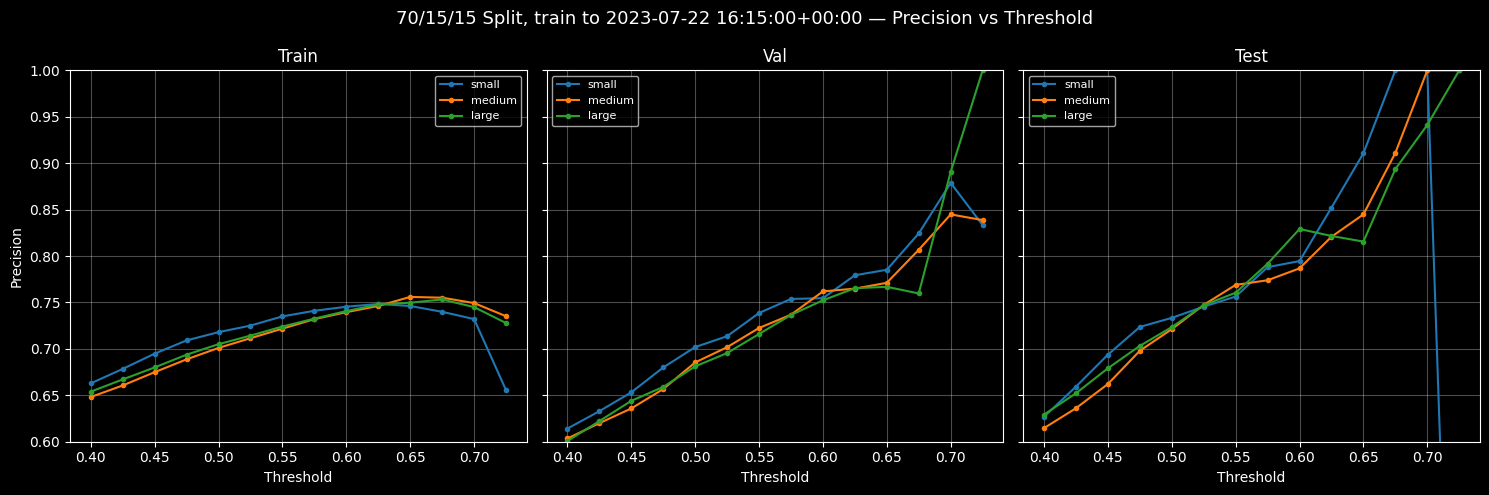

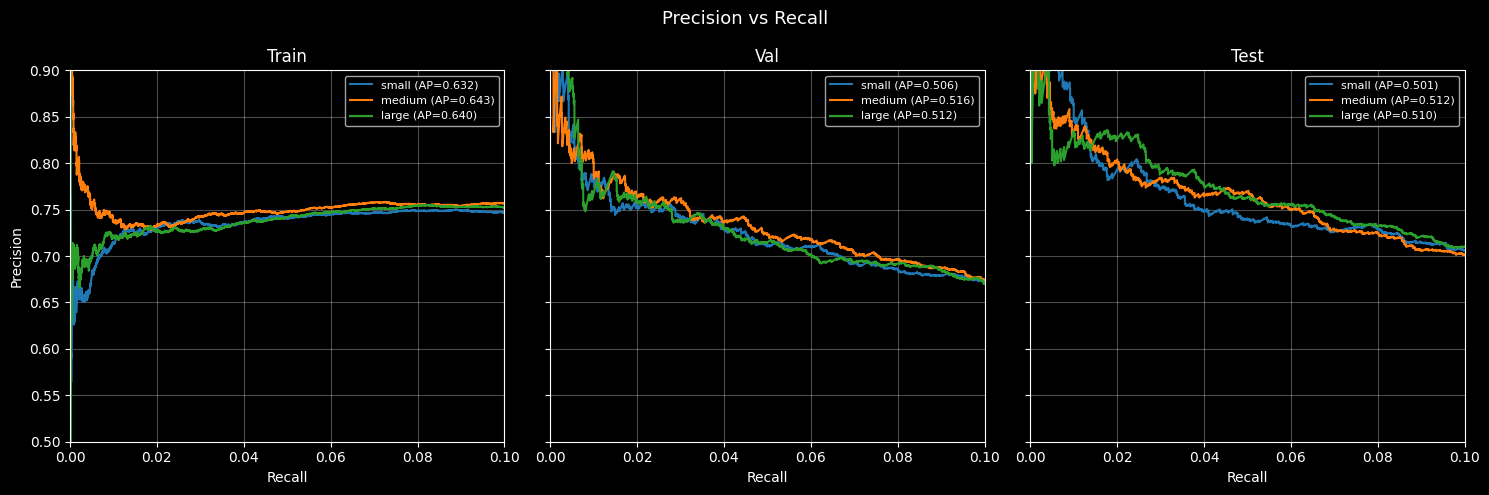

In [43]:
plot_threshold_precisions(task1_results, suptitle=f"70/15/15 Split, train to {t1_train_end} \u2014 Precision vs Threshold")
plot_precision_recall(task1_results, suptitle="Precision vs Recall")

In [34]:
# Task 2: rebuild pipeline with 31/12/2024 date cutoff
TRAIN_CUTOFF_DATE = pd.Timestamp('2024-12-31 23:45:00', tz='UTC')
last_train_idx = df_bin_final[df_bin_final[CC.TIMESTAMP_DT] <= TRAIN_CUTOFF_DATE].index[-1]
TRAIN_PCT_T2 = (last_train_idx + 1) / len(df_bin_final)
print(f"Task 2 cutoff: {TRAIN_CUTOFF_DATE}, TRAIN_PCT={TRAIN_PCT_T2:.4f}")

p2 = build_pipeline(df_bin_final, df_byb_final, TRAIN_PCT_T2)

Task 2 cutoff: 2024-12-31 23:45:00+00:00, TRAIN_PCT=0.8711
2026-03-28 15:46:23,849 [ WARNING] transform and scale all cols called on df with with segment flag col, but this arg was not passed as a parameter. 
Proceeding as though intention was to transform and scale without segmentation logic. (engineered_features.py:687)
2026-03-28 15:46:24,011 [ WARNING] transform and scale all cols called on df with with segment flag col, but this arg was not passed as a parameter. 
Proceeding as though intention was to transform and scale without segmentation logic. (engineered_features.py:687)
Building windows... done.
Train: 242596, Val: 19103, Test: 19104
Positive rate — train: 0.3990, val: 0.2865, test: 0.2251
Batch shapes — bin: (256, 96, 22), byb: (256, 96, 12)
Feature ranges — bin: [0.000, 6.100], byb: [0.000, 6.100]


2026-03-28 15:46:31.507242: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [35]:
# Class distribution for Task 2 (train to 2024-12-31, 50/50 val/test on 2025+)
print("*" * 20)
print("TASK 2: Class Distribution (train to 2024-12-31, 50/50 val/test)")
print("*" * 20)

for split_name, indices in [("Train", p2.train_indices), ("Val", p2.val_indices), ("Test", p2.test_indices)]:
    labels = p2.all_labels[indices]
    n_buy = (labels == 1).sum()
    n_no_buy = (labels == 0).sum()
    total = len(labels)

    print(f"\n{split_name:5s}: {total:7,d} samples")
    print(f"  Buy (1):    {n_buy:7,d}  ({100 * n_buy / total:5.2f}%)")
    print(f"  No Buy (0): {n_no_buy:7,d}  ({100 * n_no_buy / total:5.2f}%)")


********************
TASK 2: Class Distribution (train to 2024-12-31, 50/50 val/test)
********************

Train: 242,596 samples
  Buy (1):     96,786  (39.90%)
  No Buy (0): 145,810  (60.10%)

Val  :  19,103 samples
  Buy (1):      5,473  (28.65%)
  No Buy (0):  13,630  (71.35%)

Test :  19,104 samples
  Buy (1):      4,300  (22.51%)
  No Buy (0):  14,804  (77.49%)


In [37]:
# Task 2: Evaluate top models on train-to-2024 / 50-50 val-test split
TASK2_MODELS = {
    "medium_july_2023_train_cutoff": "./trading_models/medium_20260203_004209.keras",
    "large_july_2023_train_cutoff": "./trading_models/large_20260206_021233.keras",
    "stacked_med_d02": "./trading_models/stacked_med_d02_20260219_102113.keras",
    "large_d02": "./trading_models/large_d02_20260218_162720.keras",
    "large_d01": "./trading_models/large_d01_20260218_162720.keras",
    "medium_d02": "./trading_models/medium_d02_20260218_162720.keras",
    "medium_d01": "./trading_models/medium_d01_20260218_162720.keras",
}

# Models trained before cuDNN fix; requires weight transfer to new model architecture (or cuDNN off on both towers)
TASK2_CONFIGS = {
    "stacked_med_d02": {"bin_units": 128, "byb_units": 64, "stacked": True, "dropout_rate": 0.2},
    "large_d02": {"bin_units": 256, "byb_units": 128, "dropout_rate": 0.2},
    "large_d01": {"bin_units": 256, "byb_units": 128, "dropout_rate": 0.1},
    "medium_d02": {"bin_units": 128, "byb_units": 64, "dropout_rate": 0.2},
    "medium_d01": {"bin_units": 128, "byb_units": 64, "dropout_rate": 0.1},
    "medium_july_2023_train_cutoff": {"bin_units": 128, "byb_units": 64},
    "large_july_2023_train_cutoff": {"bin_units": 256, "byb_units": 128},
}

n_bin_features = p1.bin_features.shape[1]
n_byb_features = p1.byb_features.shape[1]

# Fair evaluation: July 2023 models use p1's scaler (matches their training),
# evaluated on p2's time-period split. d01/d02 models use p2 (matches theirs).
p1_at_p2_split = SimpleNamespace(
    train_ds=make_eval_ds(p1.bin_features, p1.byb_features, p1.all_labels, p2.train_indices),
    val_ds=make_eval_ds(p1.bin_features, p1.byb_features, p1.all_labels, p2.val_indices),
    test_ds=make_eval_ds(p1.bin_features, p1.byb_features, p1.all_labels, p2.test_indices),
    train_indices=p2.train_indices, val_indices=p2.val_indices, test_indices=p2.test_indices,
    all_labels=p1.all_labels, bin_features=p1.bin_features, byb_features=p1.byb_features,
)

task2_results = {}

for name, path in TASK2_MODELS.items():
    tf.keras.backend.clear_session()
    print(f"Loading {name} from {path}")

    # Rebuild with use_cudnn=False, then transfer weights
    model = build_dual_tower_model(
        bin_input_shape=(LSTM_WINDOW_SIZE, n_bin_features),
        byb_input_shape=(LSTM_WINDOW_SIZE, n_byb_features),
        **TASK2_CONFIGS[name]
    )

    saved = tf.keras.models.load_model(path)
    model.set_weights(saved.get_weights())
    del saved

    pipeline = p1_at_p2_split if "july_2023" in name else p2
    task2_results[name] = predict_all_subsets(model, pipeline)
    print_threshold_tables(name, task2_results[name])


tf.keras.backend.clear_session()

Loading medium_july_2023_train_cutoff from ./trading_models/medium_20260203_004209.keras

medium_july_2023_train_cutoff | Train (242,596 samples, 39.90% positive)
Threshold   Accuracy    Precision   Recall      F1          
------------------------------------------------------------
0.400       0.6884      0.6448      0.4876      0.5553      
0.425       0.6870      0.6580      0.4486      0.5335      
0.450       0.6835      0.6727      0.4027      0.5038      
0.475       0.6776      0.6873      0.3522      0.4657      
0.500       0.6716      0.7005      0.3088      0.4287      
0.525       0.6650      0.7113      0.2699      0.3914      
0.550       0.6585      0.7220      0.2342      0.3537      
0.575       0.6516      0.7322      0.1997      0.3139      
0.600       0.6438      0.7401      0.1650      0.2699      
0.625       0.6361      0.7465      0.1332      0.2261      
0.650       0.6291      0.7562      0.1038      0.1825      
0.675       0.6212      0.7558      0.0746  

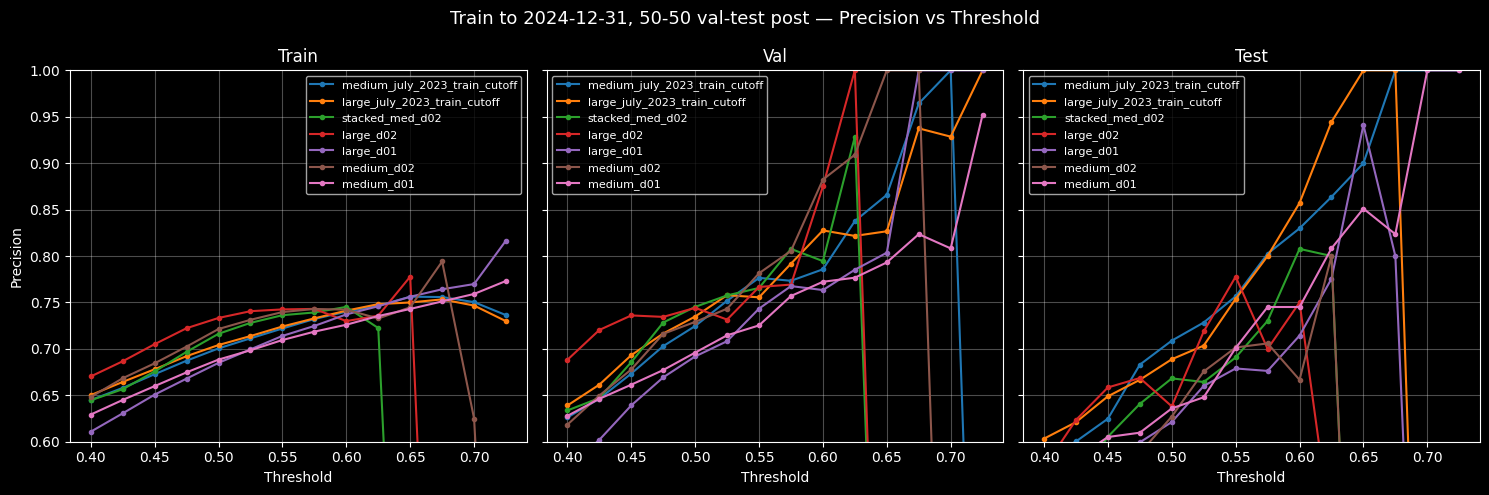

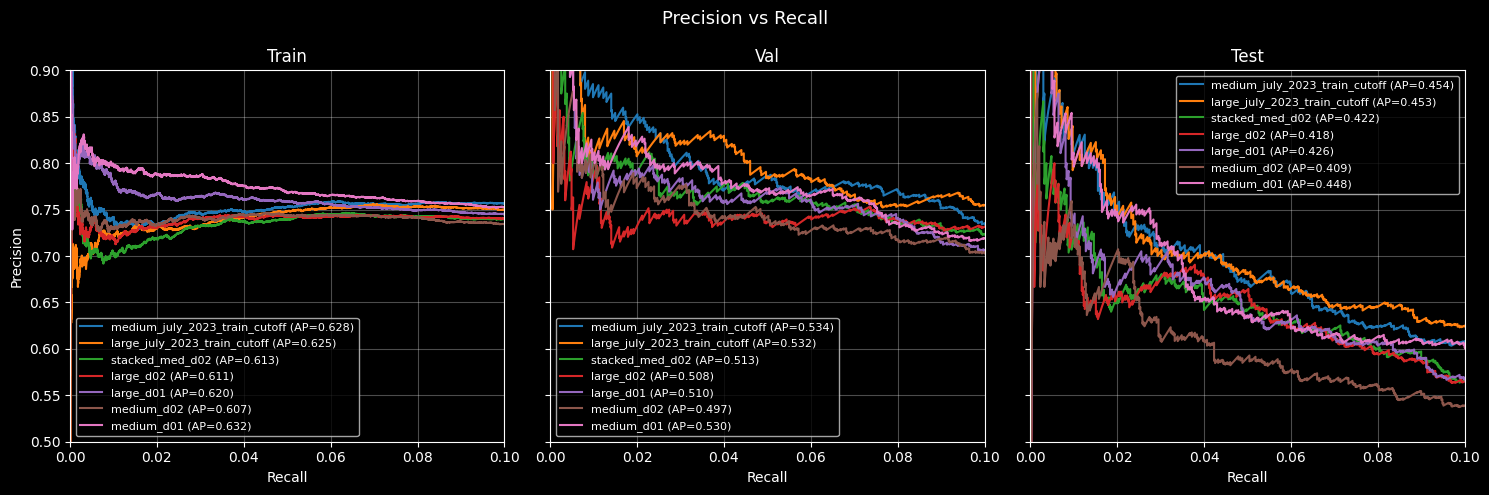

In [44]:
plot_threshold_precisions(task2_results, suptitle="Train to 2024-12-31, 50-50 val-test post \u2014 Precision vs Threshold")
plot_precision_recall(task2_results, suptitle="Precision vs Recall")